In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning, module='joblib')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import HuberRegressor, PassiveAggressiveRegressor, BayesianRidge
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.ensemble import StackingRegressor, VotingRegressor
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [65]:
df = pd.read_csv('student-mat.csv', sep=',')

In [66]:
print(df.head())

  school sex  age address famsize Parrent_status  Mother_edu  Father_edu  \
0     GP   F   18       U     GT3              A           4           4   
1     GP   F   17       U     GT3              T           1           1   
2     GP   F   15       U     LE3              T           1           1   
3     GP   F   15       U     GT3              T           4           2   
4     GP   F   16       U     GT3              T           3           3   

  Mother_job Father_job reason_to_chose_school guardian  traveltime  \
0    at_home    teacher                 course   mother           2   
1    at_home      other                 course   father           1   
2    at_home      other                  other   mother           1   
3     health   services                   home   mother           1   
4      other      other                   home   father           1   

   weekly_studytime  failures extra_edu_supp family_edu_supp extra_paid_class  \
0                 2         0      

In [67]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   school                    395 non-null    object
 1   sex                       395 non-null    object
 2   age                       395 non-null    int64 
 3   address                   395 non-null    object
 4   famsize                   395 non-null    object
 5   Parrent_status            395 non-null    object
 6   Mother_edu                395 non-null    int64 
 7   Father_edu                395 non-null    int64 
 8   Mother_job                395 non-null    object
 9   Father_job                395 non-null    object
 10  reason_to_chose_school    395 non-null    object
 11  guardian                  395 non-null    object
 12  traveltime                395 non-null    int64 
 13  weekly_studytime          395 non-null    int64 
 14  failures                  

In [68]:
#сейчас рассматриваю целевую переменную
print(f"Статистика G3:\n{df['G3'].describe()}")
print(f"\nКорреляция G3 с G1: {df['G3'].corr(df['G1']):.3f}")
print(f"Корреляция G3 с G2: {df['G3'].corr(df['G2']):.3f}")

Статистика G3:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Корреляция G3 с G1: 0.801
Корреляция G3 с G2: 0.905


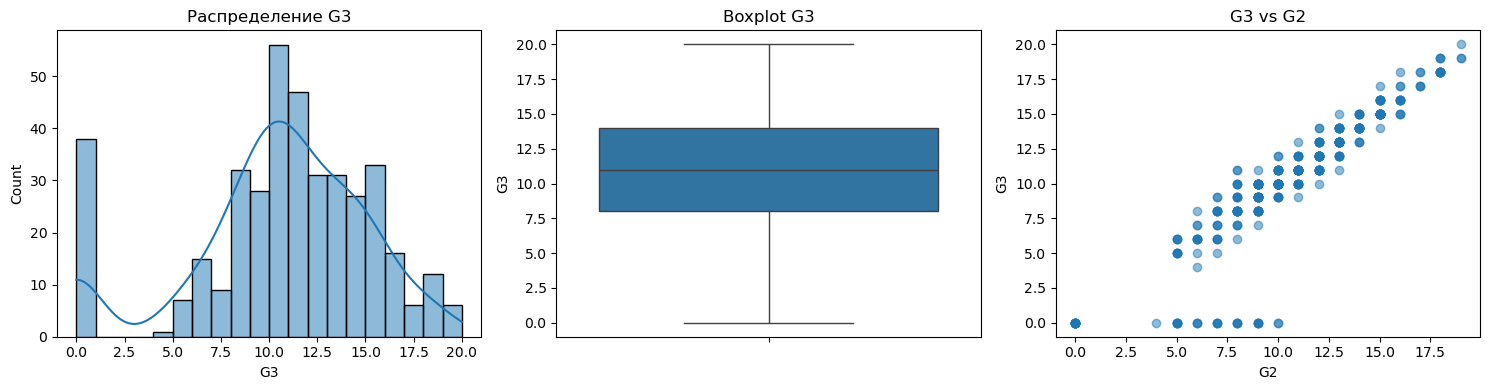

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['G3'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Распределение G3')
sns.boxplot(y=df['G3'], ax=axes[1])
axes[1].set_title('Boxplot G3')
axes[2].scatter(df['G2'], df['G3'], alpha=0.5)
axes[2].set_xlabel('G2')
axes[2].set_ylabel('G3')
axes[2].set_title('G3 vs G2')
plt.tight_layout()
plt.show()

##### по столбчатой диаграмме распределения виден выброс в левой части, однако график "ящик с усами" не характеризует соответствующие наблюдения как аномальные значения

In [70]:
USE_G1_G2 = False
X = df.drop(['G3', 'G1', 'G2'], axis=1)
y = df['G3']

In [71]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [72]:
print(f"\nКатегориальные признаки ({len(categorical_cols)}): {categorical_cols}")
print(f"Числовые признаки ({len(numerical_cols)}): {numerical_cols}")


Категориальные признаки (17): ['school', 'sex', 'address', 'famsize', 'Parrent_status', 'Mother_job', 'Father_job', 'reason_to_chose_school', 'guardian', 'extra_edu_supp', 'family_edu_supp', 'extra_paid_class', 'extra_curr_activities', 'nursery', 'Interested_in_higher_edu', 'internet_access', 'romantic_relationship']
Числовые признаки (13): ['age', 'Mother_edu', 'Father_edu', 'traveltime', 'weekly_studytime', 'failures', 'Family_quality_reln', 'freetime_after_school', 'goout_with_friends', 'workday_alcohol_consum', 'weekend_alcohol_consum', 'health_status', 'absences']


In [73]:
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (316, 30)
Размер тестовой выборки: (79, 30)


In [75]:
all_results = {} #здесь храню все результаты для дальнейшего сравнения

In [76]:
model_dummy = DummyRegressor(strategy='mean')
pipeline_dummy = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_dummy)])

start_time = time.time()
pipeline_dummy.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_dummy.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Dummy Regressor'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.64585002403461 RMSE 4.550180652162387 R2 -0.009709643515769084 Time 0.012561559677124023


In [77]:
model_lr = LinearRegression()
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_lr)])

start_time = time.time()
pipeline_lr.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Linear Regression'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.3952609258019204 RMSE 4.195680802721378 R2 0.1414924741119582 Time 0.016242265701293945


In [78]:
model_ridge = Ridge(alpha=1.0, random_state=42)
pipeline_ridge = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_ridge)])

start_time = time.time()
pipeline_ridge.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Ridge'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.3928746531567886 RMSE 4.193396549641962 R2 0.14242701357071075 Time 0.019104957580566406


In [79]:
model_lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
pipeline_lasso = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_lasso)])

start_time = time.time()
pipeline_lasso.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Lasso'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.386660401999244 RMSE 4.1945254638684295 R2 0.14196521290437958 Time 0.020720243453979492


In [80]:
model_en = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000)
pipeline_en = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_en)])

start_time = time.time()
pipeline_en.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_en.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Elastic Net'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.386098016107048 RMSE 4.191550094336398 R2 0.1431820681197321 Time 0.023914337158203125


In [81]:
model_bayesian = BayesianRidge()
pipeline_bayesian = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_bayesian)])

start_time = time.time()
pipeline_bayesian.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_bayesian.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Bayesian Ridge'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.3604522395620045 RMSE 4.157684870997741 R2 0.15697129294382217 Time 0.02270650863647461


In [82]:
model_huber = HuberRegressor(epsilon=1.35, max_iter=10000)
pipeline_huber = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_huber)])

start_time = time.time()
pipeline_huber.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_huber.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Huber'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.335824808491688 RMSE 4.212148299962042 R2 0.13474019011385974 Time 0.0318601131439209


In [83]:
model_omp = OrthogonalMatchingPursuit(n_nonzero_coefs=10)
pipeline_omp = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_omp)])

start_time = time.time()
pipeline_omp.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_omp.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['OMP'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.708480705457808 RMSE 4.46027409603934 R2 0.029797651684423054 Time 0.0208280086517334


In [84]:
model_pa = PassiveAggressiveRegressor(C=1.0, random_state=42, max_iter=10000)
pipeline_pa = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_pa)])

start_time = time.time()
pipeline_pa.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_pa.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Passive Aggressive'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 4.462746169785923 RMSE 5.708565424576027 R2 -0.5892535520957358 Time 0.02243351936340332


In [85]:
model_dt = DecisionTreeRegressor(max_depth=10, random_state=42)
pipeline_dt = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_dt)])

start_time = time.time()
pipeline_dt.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_dt.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Decision Tree'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.469927119294208 RMSE 4.440957993830296 R2 0.038182763241913276 Time 0.024461030960083008


In [86]:
model_knn = KNeighborsRegressor(n_neighbors=5)
pipeline_knn = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_knn)])

start_time = time.time()
pipeline_knn.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_knn.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['KNN'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.6405063291139244 RMSE 4.643002084258673 R2 -0.05132497733879271 Time 0.018440961837768555


In [87]:
model_rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=1)
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_rf)])

start_time = time.time()
pipeline_rf.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Random Forest'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 2.989418715110146 RMSE 3.7620314867284352 R2 0.3097855019735819 Time 0.3692750930786133


In [88]:
model_et = ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=1)
pipeline_et = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_et)])

start_time = time.time()
pipeline_et.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_et.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Extra Trees'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.336959586206681 RMSE 4.331270908274982 R2 0.08510780611145718 Time 0.32921266555786133


In [89]:
model_ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
pipeline_ada = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_ada)])

start_time = time.time()
pipeline_ada.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_ada.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['AdaBoost'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.5623425785385052 RMSE 4.307890698580434 R2 0.09495832765928791 Time 0.2956209182739258


In [90]:
model_gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
pipeline_gb = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_gb)])

start_time = time.time()
pipeline_gb.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_gb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Gradient Boosting'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 2.986236428596231 RMSE 3.727335664478301 R2 0.32245797953714006 Time 0.13797378540039062


In [91]:
model_xgb = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0, n_jobs=1)
pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_xgb)])

start_time = time.time()
pipeline_xgb.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['XGBoost'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 2.898327112197876 RMSE 3.628993761138725 R2 0.3577389121055603 Time 0.04070591926574707


In [92]:
model_lgbm = lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1, n_jobs=1)
pipeline_lgbm = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_lgbm)])

start_time = time.time()
pipeline_lgbm.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_lgbm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['LightGBM'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.2120369399941917 RMSE 3.971369662013339 R2 0.23083439963962138 Time 0.02667689323425293


In [93]:
model_cat = CatBoostRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=0, thread_count=1)
pipeline_cat = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_cat)])

start_time = time.time()
pipeline_cat.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_cat.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['CatBoost'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.2380851444575742 RMSE 4.015257724801094 R2 0.21374018865670885 Time 0.14760756492614746


In [94]:
base_learners = [
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=1)),
    ('gb', GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42)),
    ('ridge', Ridge(alpha=1.0))
]

model_stack = StackingRegressor(
    estimators=base_learners,
    final_estimator=LinearRegression(),
    cv=3,
    n_jobs=1
)

pipeline_stack = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_stack)])

start_time = time.time()
pipeline_stack.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = pipeline_stack.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

all_results['Stacking Ensemble'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Time': train_time}
print('MAE', mae, 'RMSE', rmse, 'R2', r2, 'Time', train_time)

MAE 3.1554766320230567 RMSE 3.9362087384514095 R2 0.24439387873098206 Time 0.6085724830627441


In [95]:
results_df = pd.DataFrame([
    {
        'Модель': name,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R2': metrics['R2'],
        'Время (сек)': metrics['Time']
    }
    for name, metrics in all_results.items()
])

In [96]:
results_df = results_df.sort_values('RMSE').reset_index(drop=True)

In [97]:
results_df['Ранг'] = range(1, len(results_df) + 1)

In [98]:
print(results_df[['Ранг', 'Модель', 'MAE', 'RMSE', 'R2', 'Время (сек)']].to_string(index=False))

 Ранг             Модель      MAE     RMSE        R2  Время (сек)
    1            XGBoost 2.898327 3.628994  0.357739     0.040706
    2  Gradient Boosting 2.986236 3.727336  0.322458     0.137974
    3      Random Forest 2.989419 3.762031  0.309786     0.369275
    4  Stacking Ensemble 3.155477 3.936209  0.244394     0.608572
    5           LightGBM 3.212037 3.971370  0.230834     0.026677
    6           CatBoost 3.238085 4.015258  0.213740     0.147608
    7     Bayesian Ridge 3.360452 4.157685  0.156971     0.022707
    8        Elastic Net 3.386098 4.191550  0.143182     0.023914
    9              Ridge 3.392875 4.193397  0.142427     0.019105
   10              Lasso 3.386660 4.194525  0.141965     0.020720
   11  Linear Regression 3.395261 4.195681  0.141492     0.016242
   12              Huber 3.335825 4.212148  0.134740     0.031860
   13           AdaBoost 3.562343 4.307891  0.094958     0.295621
   14        Extra Trees 3.336960 4.331271  0.085108     0.329213
   15     

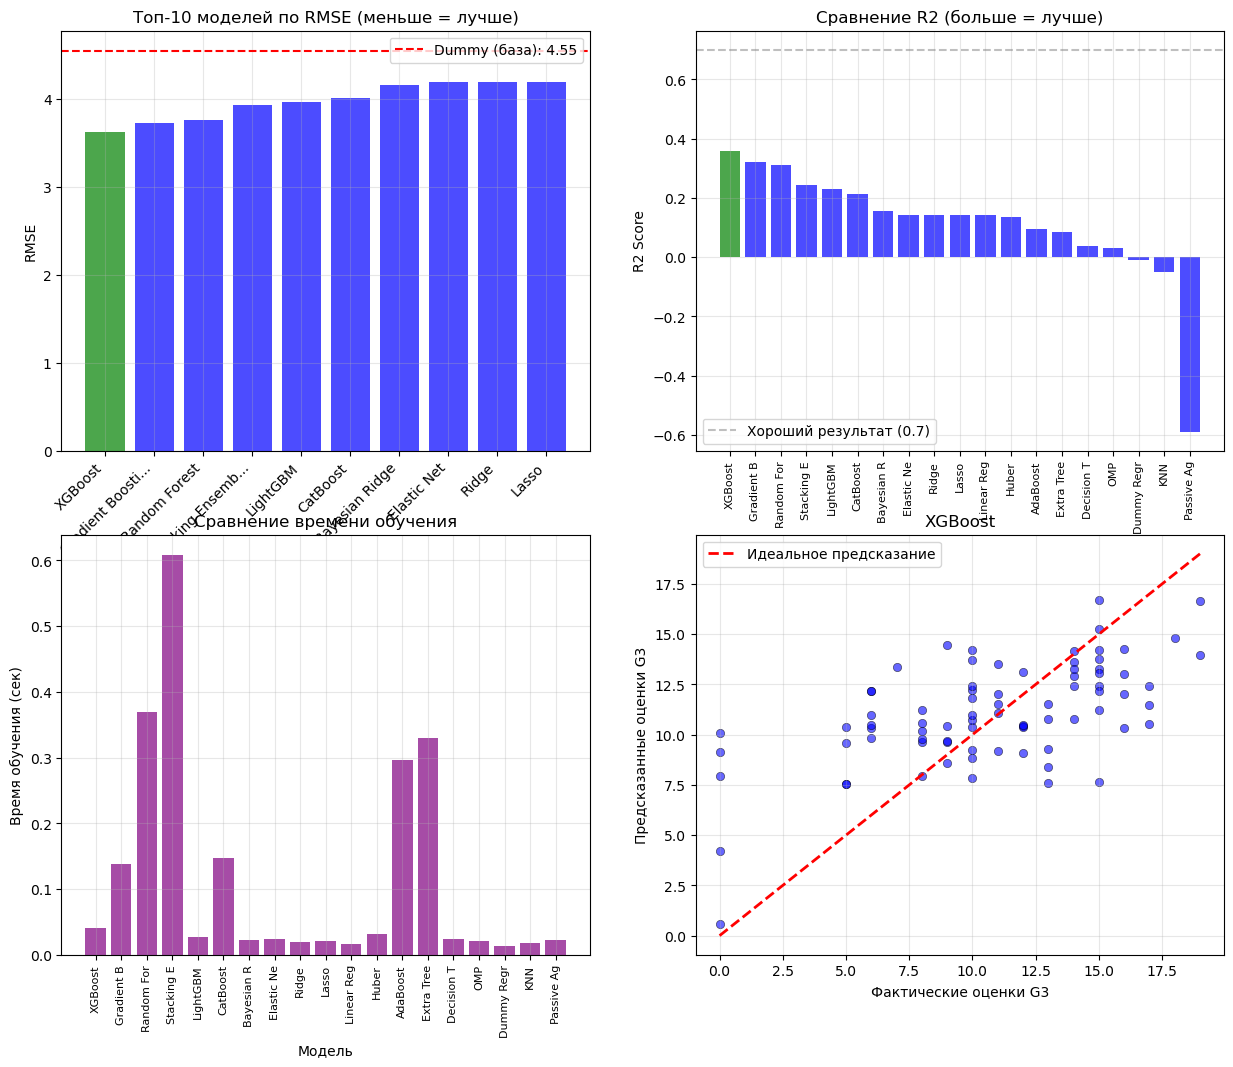

In [99]:
best_model = results_df.iloc[0]
worst_model = results_df.iloc[-1]
# Разница между лучшей и базовой (Dummy)
dummy_rmse = all_results['Dummy Regressor']['RMSE']
best_rmse = best_model['RMSE']
improvement = ((dummy_rmse - best_rmse) / dummy_rmse) * 100
fig, axes2 = plt.subplots(2, 2, figsize=(15, 12))
ax1 = axes2[0, 0]
top_models = results_df.head(10)
colors = ['green' if i == 0 else 'blue' for i in range(len(top_models))]
bars = ax1.bar(range(len(top_models)), top_models['RMSE'], color=colors, alpha=0.7)
ax1.set_xlabel('Модель')
ax1.set_ylabel('RMSE')
ax1.set_title('Топ-10 моделей по RMSE (меньше = лучше)')
ax1.set_xticks(range(len(top_models)))
ax1.set_xticklabels([m[:15] + '...' if len(m) > 15 else m for m in top_models['Модель']], rotation=45, ha='right')
ax1.axhline(y=dummy_rmse, color='red', linestyle='--', label=f'Dummy (база): {dummy_rmse:.2f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes2[0, 1]
colors_r2 = ['green' if x == best_model['R2'] else 'blue' for x in results_df['R2']]
bars = ax2.bar(range(len(results_df)), results_df['R2'], color=colors_r2, alpha=0.7)
ax2.set_xlabel('Модель')
ax2.set_ylabel('R2 Score')
ax2.set_title('Сравнение R2 (больше = лучше)')
ax2.set_xticks(range(len(results_df)))
ax2.set_xticklabels([m[:10] for m in results_df['Модель']], rotation=90, fontsize=8)
ax2.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='Хороший результат (0.7)')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes2[1, 0]
ax3.bar(range(len(results_df)), results_df['Время (сек)'], color='purple', alpha=0.7)
ax3.set_xlabel('Модель')
ax3.set_ylabel('Время обучения (сек)')
ax3.set_title('Сравнение времени обучения')
ax3.set_xticks(range(len(results_df)))
ax3.set_xticklabels([m[:10] for m in results_df['Модель']], rotation=90, fontsize=8)
ax3.grid(True, alpha=0.3)

best_model_name = best_model['Модель']
if 'Random Forest' in best_model_name:
    best_pipeline = pipeline_rf
elif 'XGBoost' in best_model_name:
    best_pipeline = pipeline_xgb
elif 'LightGBM' in best_model_name:
    best_pipeline = pipeline_lgbm
elif 'CatBoost' in best_model_name:
    best_pipeline = pipeline_cat
elif 'Gradient Boosting' in best_model_name:
    best_pipeline = pipeline_gb
elif 'Extra Trees' in best_model_name:
    best_pipeline = pipeline_et
elif 'Stacking' in best_model_name:
    best_pipeline = pipeline_stack
else:
    best_pipeline = pipeline_rf  # По умолчанию

y_pred_best = best_pipeline.predict(X_test)

ax4 = axes2[1, 1]
ax4.scatter(y_test, y_pred_best, alpha=0.6, color='blue', edgecolors='black', linewidth=0.5)
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
ax4.set_xlabel('Фактические оценки G3')
ax4.set_ylabel('Предсказанные оценки G3')
ax4.set_title(f'Предсказания лучшей модели: {best_model_name[:40]}...' if len(best_model_name) > 40 else best_model_name)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.show()

### Лучше всего на данных показал себя XGBoost - это наилучшая модель из построенных